In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")



In [64]:
data = pd.read_csv("heart.csv")
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA


In [65]:
data.shape

(918, 12)

In [66]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [68]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

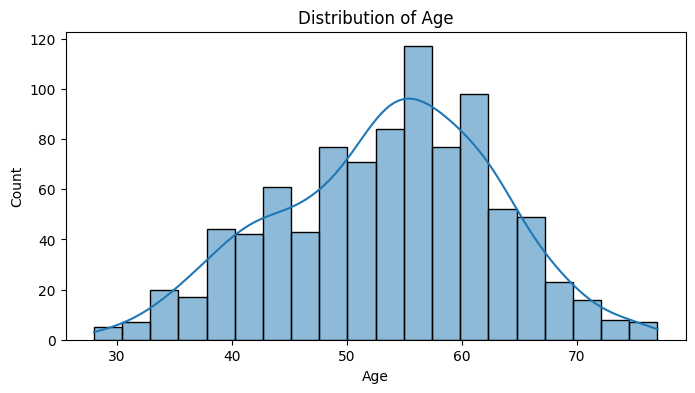

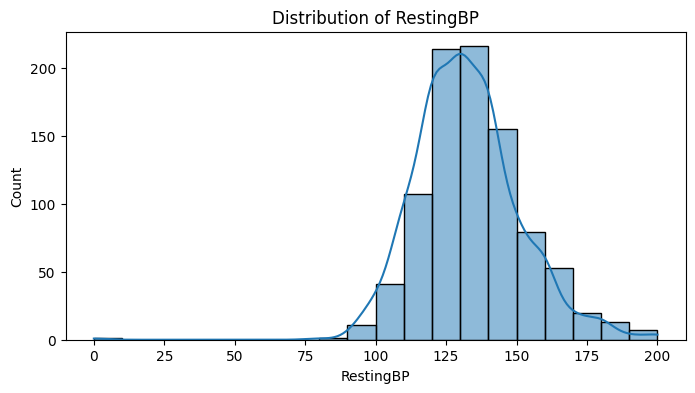

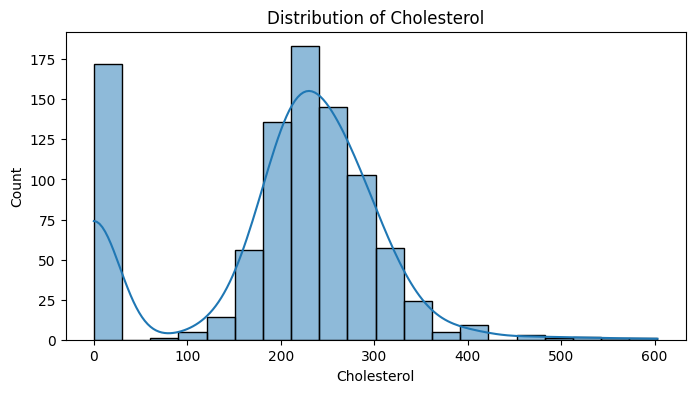

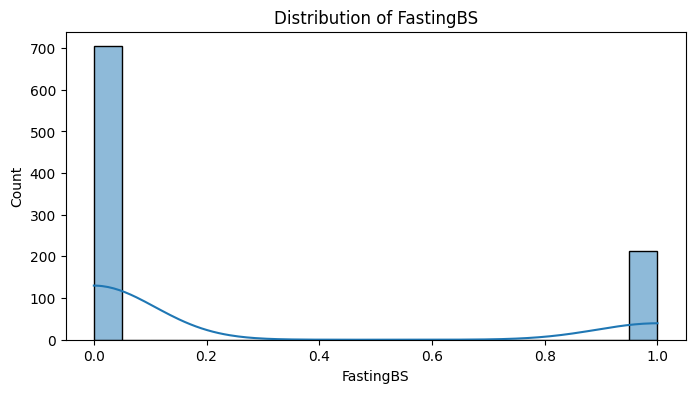

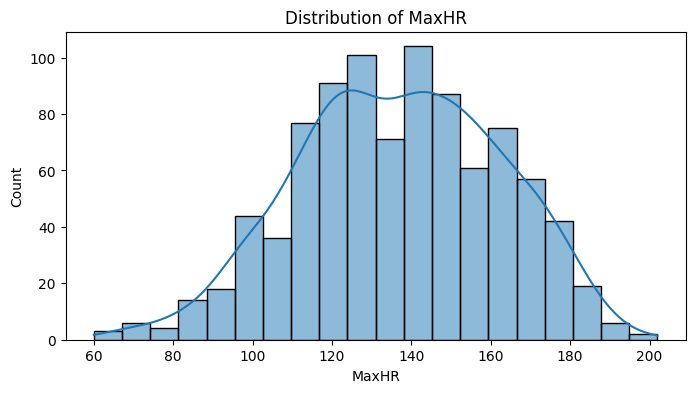

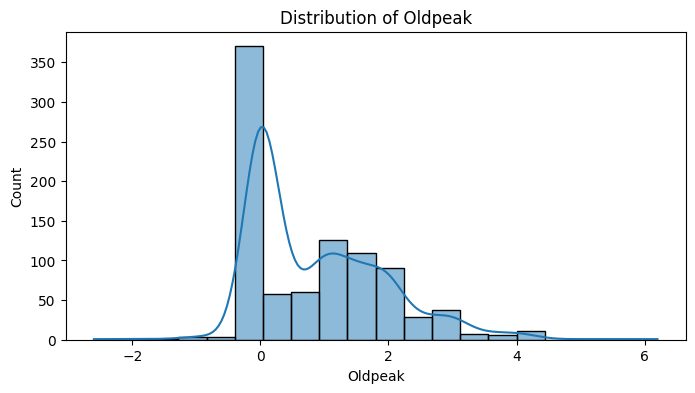

In [69]:
numeric_columns=['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
for i in numeric_columns:
    plt.figure(figsize=(8, 4)) 
    sns.histplot(data[i], kde=True, bins=20)
    plt.title(f'Distribution of {i}') 

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


<Axes: xlabel='Sex', ylabel='count'>

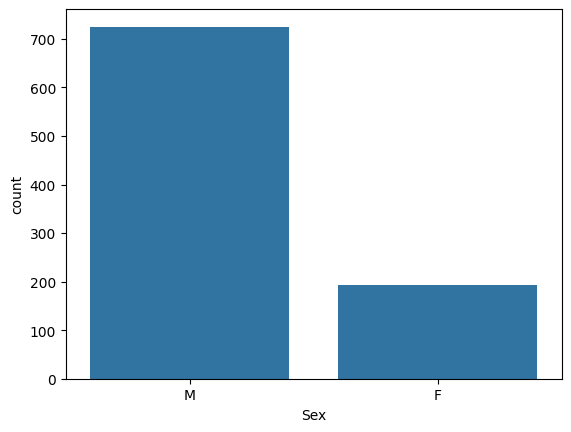

In [71]:
sns.countplot(x=(data['Sex']))

<Axes: xlabel='ChestPainType', ylabel='count'>

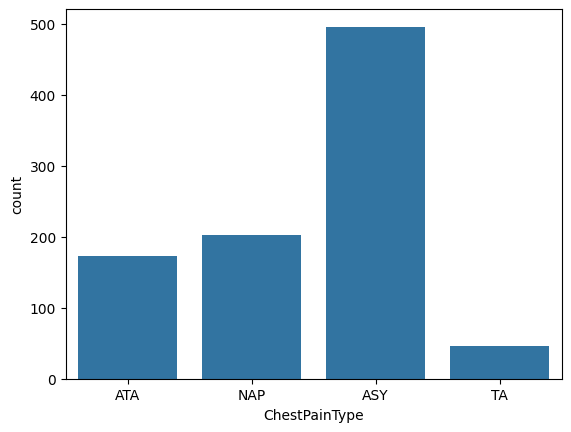

In [72]:
sns.countplot(x=(data['ChestPainType']))


<Axes: xlabel='RestingECG', ylabel='count'>

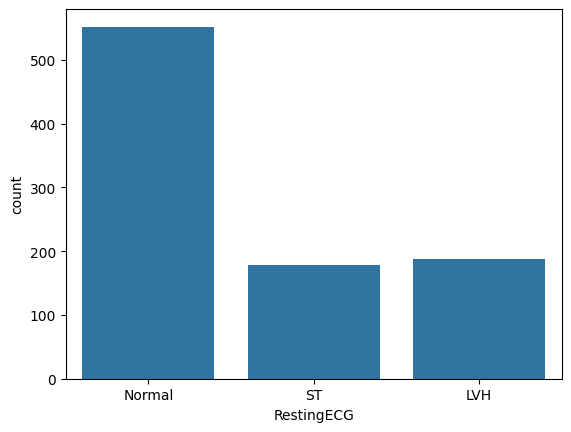

In [73]:
sns.countplot(x=(data['RestingECG']))


<Axes: xlabel='ST_Slope', ylabel='count'>

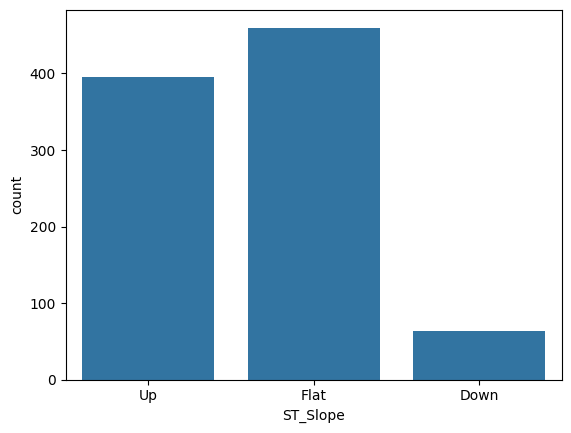

In [74]:
sns.countplot(x=(data['ST_Slope']))

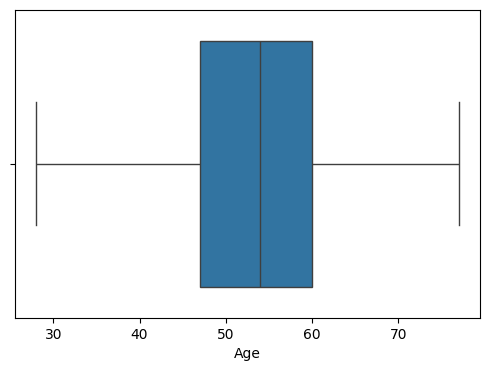

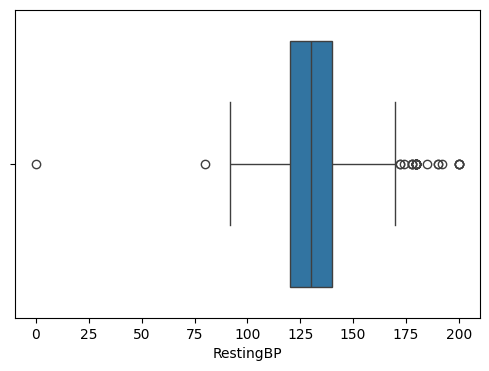

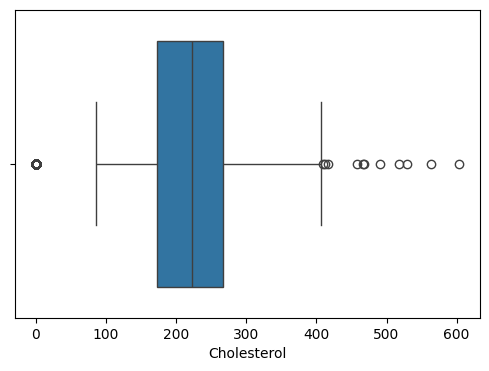

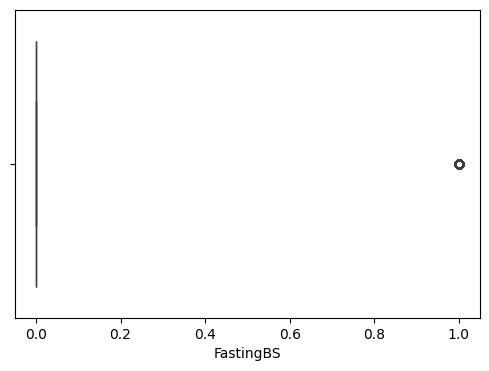

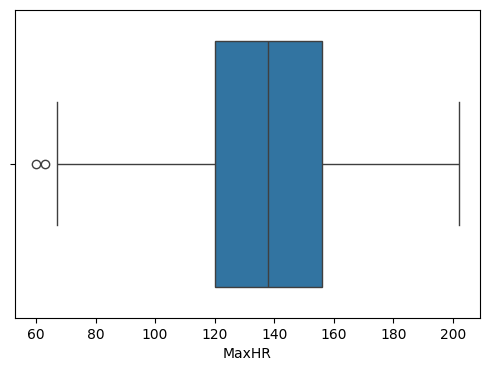

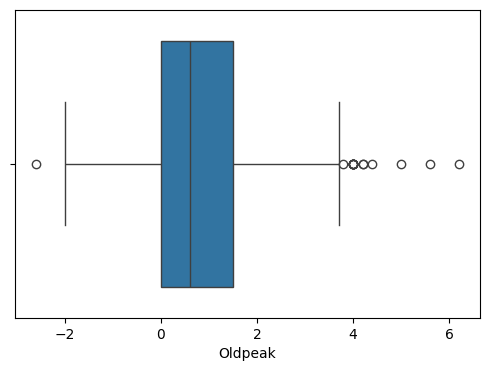

In [75]:
for i in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[i])

<Axes: >

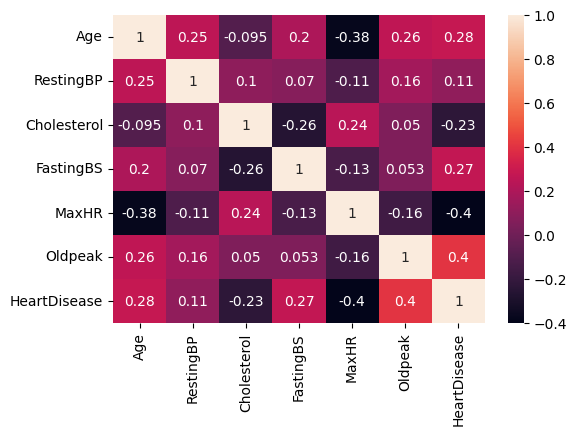

In [76]:
plt.figure(figsize=(6, 4))
sns.heatmap(data.corr(numeric_only=True), annot=True)


Data Cleaning and Preprocessing

In [77]:
data_cleaned=data.copy()

In [78]:
data_cleaned.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [79]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [80]:
data_cleaned.drop_duplicates(inplace=True)

In [81]:
data_cleaned.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [82]:
data_cleaned['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [83]:
data_cleaned['Sex'] = data_cleaned['Sex'].map({'M': 0, 'F': 1})
data_cleaned.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [84]:
data_cleaned['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [ ]:
data_cleaned=pd.get_dummies(data_cleaned, columns=['ChestPainType'], drop_first=True)
data_cleaned.head()


,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,0,140,289,0,Normal,172,N,0.0,Up,0,True,False,False
1,49,1,160,180,0,Normal,156,N,1.0,Flat,1,False,True,False
2,37,0,130,283,0,ST,98,N,0.0,Up,0,True,False,False
3,48,1,138,214,0,Normal,108,Y,1.5,Flat,1,False,False,False
4,54,0,150,195,0,Normal,122,N,0.0,Up,0,False,True,False


In [86]:
data_cleaned['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [ ]:
data_cleaned=pd.get_dummies(data_cleaned, columns=['RestingECG'], drop_first=True ,)
data_cleaned.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,0,140,289,0,172,N,0.0,Up,0,True,False,False,True,False
1,49,1,160,180,0,156,N,1.0,Flat,1,False,True,False,True,False
2,37,0,130,283,0,98,N,0.0,Up,0,True,False,False,False,True
3,48,1,138,214,0,108,Y,1.5,Flat,1,False,False,False,True,False
4,54,0,150,195,0,122,N,0.0,Up,0,False,True,False,True,False


In [ ]:
data_cleaned=pd.get_dummies(data_cleaned, columns=['ExerciseAngina'], drop_first=True )
data_cleaned.head()

KeyError: "None of [Index(['ExerciseAngina'], dtype='object')] are in the [columns]"

In [90]:
data_cleaned=pd.get_dummies(data_cleaned, columns=['ST_Slope'], drop_first=True ,)
data_cleaned.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0.0,0,True,False,False,True,False,False,False,True
1,49,1,160,180,0,156,1.0,1,False,True,False,True,False,False,True,False
2,37,0,130,283,0,98,0.0,0,True,False,False,False,True,False,False,True
3,48,1,138,214,0,108,1.5,1,False,False,False,True,False,True,True,False
4,54,0,150,195,0,122,0.0,0,False,True,False,True,False,False,False,True


In [91]:
data_cleaned=data_cleaned.astype(int)
data_cleaned.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,1,0,0,1,0,0,0,1
1,49,1,160,180,0,156,1,1,0,1,0,1,0,0,1,0
2,37,0,130,283,0,98,0,0,1,0,0,0,1,0,0,1
3,48,1,138,214,0,108,1,1,0,0,0,1,0,1,1,0
4,54,0,150,195,0,122,0,0,0,1,0,1,0,0,0,1


In [96]:
data_cleaned.rename(columns={
    'Sex': 'IsFemale',
    'ChestPainType_ATA': 'IsChestPainType_ATA',
    'ChestPainType_NAP': 'IsChestPainType_NAP',
    'ChestPainType_TA': 'IsChestPainType_TA',
    'RestingECG_Normal': 'IsRestingECG_Normal',
    'RestingECG_ST': 'IsRestingECG_ST',
    'ExerciseAngina_Y': 'IsExerciseAngina_Y',
    'ST_Slope_Flat': 'IsST_Slope_Flat',
    'ST_Slope_Up': 'IsST_Slope_Up'
}, inplace=True)

data_cleaned.head()

,Age,IsFemale,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,IsChestPainType_ATA,IsChestPainType_NAP,IsChestPainType_TA,IsRestingECG_Normal,IsRestingECG_ST,IsExerciseAngina_Y,IsST_Slope_Flat,IsST_Slope_Up
0,40,0,140,289,0,172,0,0,1,0,0,1,0,0,0,1
1,49,1,160,180,0,156,1,1,0,1,0,1,0,0,1,0
2,37,0,130,283,0,98,0,0,1,0,0,0,1,0,0,1
3,48,1,138,214,0,108,1,1,0,0,0,1,0,1,1,0
4,54,0,150,195,0,122,0,0,0,1,0,1,0,0,0,1


Feature Scaling & Extraction


In [101]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_cleaned[['temp_age', 'temp_hr']] = scaler.fit_transform(data_cleaned[['Age', 'MaxHR']])
data_cleaned['Heart_Efficiency_Score'] = ((1 - data_cleaned['temp_age']) + data_cleaned['temp_hr']) / 2
data_cleaned.drop(columns=['temp_age', 'temp_hr'], inplace=True)
data_cleaned.head()

,Age,IsFemale,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,IsChestPainType_ATA,IsChestPainType_NAP,IsChestPainType_TA,IsRestingECG_Normal,IsRestingECG_ST,IsExerciseAngina_Y,IsST_Slope_Flat,IsST_Slope_Up,Age_Scaled,MaxHR_Scaled,Heart_Efficiency_Score
0,-1.433140,0,0.410909,0.825070,0,1.382928,0,0,1,0,0,1,0,0,0,1,0.244898,0.788732,0.771917
1,-0.478484,1,1.491752,-0.171961,0,0.754157,1,1,0,1,0,1,0,0,1,0,0.428571,0.676056,0.623742
2,-1.751359,0,-0.129513,0.770188,0,-1.525138,0,0,1,0,0,0,1,0,0,1,0.183673,0.267606,0.541966
3,-0.584556,1,0.302825,0.139040,0,-1.132156,1,1,0,0,0,1,0,1,1,0,0.408163,0.338028,0.464932
4,0.051881,0,0.951331,-0.034755,0,-0.581981,0,0,0,1,0,1,0,0,0,1,0.530612,0.436620,0.453004


In [98]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
cols=['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
data_cleaned[cols]=scaler.fit_transform(data_cleaned[cols])
data_cleaned.head()

,Age,IsFemale,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,IsChestPainType_ATA,IsChestPainType_NAP,IsChestPainType_TA,IsRestingECG_Normal,IsRestingECG_ST,IsExerciseAngina_Y,IsST_Slope_Flat,IsST_Slope_Up
0,-1.433140,0,0.410909,0.825070,0,1.382928,0,0,1,0,0,1,0,0,0,1
1,-0.478484,1,1.491752,-0.171961,0,0.754157,1,1,0,1,0,1,0,0,1,0
2,-1.751359,0,-0.129513,0.770188,0,-1.525138,0,0,1,0,0,0,1,0,0,1
3,-0.584556,1,0.302825,0.139040,0,-1.132156,1,1,0,0,0,1,0,1,1,0
4,0.051881,0,0.951331,-0.034755,0,-0.581981,0,0,0,1,0,1,0,0,0,1


In [103]:
data_cleaned.columns

Index(['Age', 'IsFemale', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'Oldpeak', 'HeartDisease', 'IsChestPainType_ATA', 'IsChestPainType_NAP',
       'IsChestPainType_TA', 'IsRestingECG_Normal', 'IsRestingECG_ST',
       'IsExerciseAngina_Y', 'IsST_Slope_Flat', 'IsST_Slope_Up', 'Age_Scaled',
       'MaxHR_Scaled', 'Heart_Efficiency_Score'],
      dtype='object')

In [106]:
from scipy.stats import chi2_contingency, pointbiserialr
import pandas as pd

cont_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Age_Scaled', 'MaxHR_Scaled', 'Heart_Efficiency_Score']
cat_features = ['IsFemale', 'FastingBS', 'IsChestPainType_ATA', 'IsChestPainType_NAP', 'IsChestPainType_TA', 'IsRestingECG_Normal', 'IsRestingECG_ST', 'IsExerciseAngina_Y', 'IsST_Slope_Flat', 'IsST_Slope_Up']

alpha = 0.05
results = []

for col in cat_features:
    contingency = pd.crosstab(data_cleaned[col], data_cleaned['HeartDisease'])
    _, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    results.append({'Feature': col, 'p_value': p_val, 'Decision': decision})

for col in cont_features:
    _, p_val = pointbiserialr(data_cleaned[col], data_cleaned['HeartDisease'])
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    results.append({'Feature': col, 'p_value': p_val, 'Decision': decision})

chi2_df = pd.DataFrame(results).sort_values(by='p_value').reset_index(drop=True)
print(chi2_df)


                   Feature       p_value                    Decision
0            IsST_Slope_Up  1.028493e-78  Reject Null (Keep Feature)
1          IsST_Slope_Flat  8.906496e-63  Reject Null (Keep Feature)
2       IsExerciseAngina_Y  2.907808e-50  Reject Null (Keep Feature)
3   Heart_Efficiency_Score  4.184857e-38  Reject Null (Keep Feature)
4             MaxHR_Scaled  1.137786e-36  Reject Null (Keep Feature)
5                    MaxHR  1.137786e-36  Reject Null (Keep Feature)
6                  Oldpeak  3.699537e-35  Reject Null (Keep Feature)
7      IsChestPainType_ATA  1.152597e-33  Reject Null (Keep Feature)
8                 IsFemale  4.597617e-20  Reject Null (Keep Feature)
9               Age_Scaled  3.007953e-18  Reject Null (Keep Feature)
10                     Age  3.007953e-18  Reject Null (Keep Feature)
11               FastingBS  1.057302e-15  Reject Null (Keep Feature)
12             Cholesterol  9.308309e-13  Reject Null (Keep Feature)
13     IsChestPainType_NAP  1.8597